# Using Supernova type 1a to Constrain Cosmological Parameters

Supernova Type 1a (SN1a) are considered 'standard candles' because their absolute magnitudes are approximately known, no matter where they occur. Thus, we can use the apparent magnitude of a SN1a to measure the distance to the supernova. SN1a are especially important on the distance ladder because they are so bright and as such can be seen very far away, up to ~z=2 so far---even farther than Cepheid variable stars. 

At very large distances, the shape of the universe affects the apparent brightness of an object. This is because the effects of the curvature of spacetime become appreciable at high distances, or high redshifts--apparent brightness no longer decreases with the square of proper distance. The distance at which an object with luminosity L appears at flux F is called the luminosity distance: $F = \frac{L}{2\pi d_L^2}$. This relationship can also be expressed with magnitudes, using the typical relationship: $M=m-5log_{10}(\frac{d_L}{10 pc})$. The luminosity distance is very close to the proper distance at small redshifts, and the relationship between proper distance and luminosity distance depends on properties of the universe such as geometry and expansion. As such, SN1a observed at high redshifts can be used as a probe of the parameters that define the universe. 

In this notebook, I gather data from observations of SN1a in the literature and use them to estimate cosmological parameters. I begin with a short section about the data and corrections to improve the data quality, then attempt two fitting methods: non-linear least squares and MCMC. I conclude by comparing my results to the literature and discussing the Hubble Tension.

In [166]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as c
from astropy.table import Table
from astropy.io import ascii
from scipy.integrate import quad 

# Data and Absolute Magnitude Corrections

The three datasets used here are:
1. Betoule et al. 2014 Dataset
   
   This dataset contains, for 740 SN1a: redshift with respect to the CMB, maximum apparent B-band magnitude, magnitude error, and model parameters, amongst other information not needed for this project. The B-band magnitudes were corrected for selection bias by Betoule et al.
2. Supernova Cosmology Project Union Dataset
   
   This dataset contains redshift with respect to the CMB, distance modulus, and error for 580 SN1a. These data are pre-corrected by the SCP Union for stretch, color, and selection bias.
3. Pantheon + SH0ES dataset
   
    This dataset contains redshift with respect to the CMB, maximum apparent B magnitude, error, and model parameters for 1701 SN1a. The B-band magnitudes have been corrected for selection bias by the Pantheon+SH0ES team.

In [167]:
#Data from Betoule et. al 2014
B_data = ascii.read('Betoule_SN1AData.txt')['zcmb', 'mb', 'dmb', 'x1']

#Data from SCP Union 
SCP_data = ascii.read('SCPUnion_SN1aData.txt')['zcmb', 'DM', 'errDM']
#This data is pre-corrected for stretch w/absolute magnitude, data given in in DM

#Data from Pantheon and SH0ES
PS_data = ascii.read('Pantheon_SH0ES_SN1aData.dat', delimiter=' ')['zcmb', 'mb', 'x1', 'm_b_corr_err_DIAG']

SN1a are not, in reality, perfect standard candles. The assumption that all SN1a have the same maximum absolute magnitude is not completely correct---in fact, it has been found that the maximum absolute magnitudes of SN1a change by ~0.1 magnitudes, and the maximum absolute magnitude is related to the time a SN1a takes to fade and the color. The most simple correction that can be made in the assumed max absolute magnitude was discovered by Bert Rust and Yury Pskovskii in the 1970s, but was revised by Mark Phillips in the 1990s, and is called the Phillips Relation. For B-band;
\begin{equation}
M_{max} = -21.726 + 2.698 \Delta m_{15},
\end{equation}
where $\Delta m_{15}$ is the change in the magnitude from the peak to 15 days after the supernova. Common SN1a fitting algorithms---like SALT2 (Guy et al. 2007), which was used in to process all three datasets we employ---use proxies for this relationship like the factor $x_1$. According to the SALT2 paper, $x_1$ can be converted approximately to $\Delta m_{15}$ with the equation:
\begin{equation}
\Delta m_{15} = 1.09 - 0.161x_1.
\end{equation}

The Pantheon and SH0ES datasets have already used max absolute magnitude corrections, as they present distance moduli rather than B-band magnitudes, so we can apply the Phillips relation to the Betoule and SCP Union datasets:

In [168]:
#Calculate stretch factors for B and PS datasets using x1:
B_data['delta m 15'] = 1.09 - B_data['x1']*0.161 
PS_data['delta m 15'] = 1.09 - PS_data['x1']*0.161

In [169]:
#Set up Phillips relationship
def Phillips(dm15):
    '''Function to apply the Phillips relation to correct for delta m15 in max absolute magnitude
    '''
    M0 = -21.726 + 2.698*dm15
    return M0

In [170]:
#Calculate absolute magnitudes using Phillips relationship
PS_data['Abs Mag'] = Phillips(PS_data['delta m 15'])
PS_data['Err Abs Mag'] = np.std(PS_data['Abs Mag']) #Estimate of error on absolute magnitudes

B_data['Abs Mag'] = Phillips(B_data['delta m 15'])
B_data['Err Abs Mag'] = np.std(B_data['Abs Mag']) #Estimate of error on absolute magnitudes

With absolute and apparent magnitudes, we can calculate the distance moduli (difference between apparent and absolute magnitudes):

In [171]:
#Calculate distance moduli:
B_data['DM'] = B_data['mb'] - B_data['Abs Mag']
B_data['DM Err'] = np.sqrt(B_data['dmb']**2 + B_data['Err Abs Mag']**2) #Rough estimate of error

PS_data['DM'] = PS_data['mb'] - PS_data['Abs Mag']
PS_data['DM Err'] = np.sqrt(PS_data['m_b_corr_err_DIAG']**2 + PS_data['Err Abs Mag']**2) #Rough estimate of error


The plots below show the distributions of absolute magnitude and stretch factor between dataset B and dataset PS.

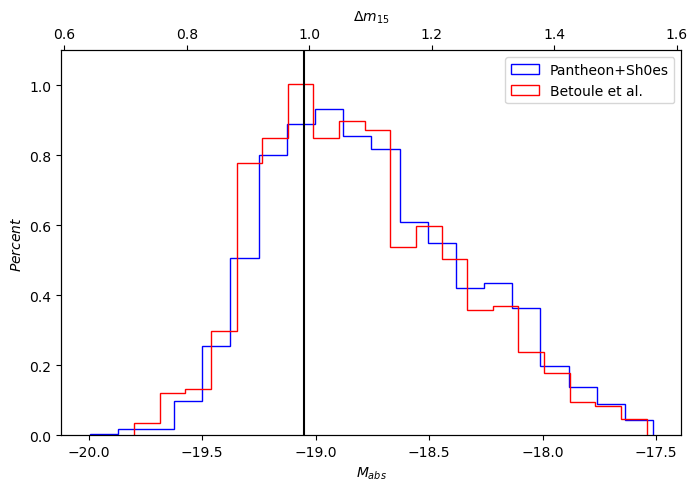

In [172]:
from astropy.visualization import hist

fig = plt.figure (figsize=(8,5))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()

ax1.hist(PS_data['Abs Mag'], bins=20, color='b', histtype='step', density=True, label='Pantheon+Sh0es')
ax1.hist(B_data['Abs Mag'], bins=20, color='r', histtype='step', density=True, label='Betoule et al.')

ax2.hist(PS_data['delta m 15'], bins=10, color='b', histtype='step', density=True, label='Pantheon+Sh0es', alpha=0)
ax2.hist(B_data['delta m 15'], bins=10, color='r', histtype='step', density=True, label='Betoule et al.', alpha=0)

ax2.set_ylim(0,1.1)
#Typical abs M value:
M0sn = -19.05
ax1.axvline(M0sn, color='k')
ax1.set_xlabel(r'$M_{abs}$')
ax2.set_xlabel(r'$\Delta m_{15}$')
ax1.set_ylabel(r'$Percent$')
ax1.legend()

Now, we can explore the distance moduli of all three datasets as a function of redshift.

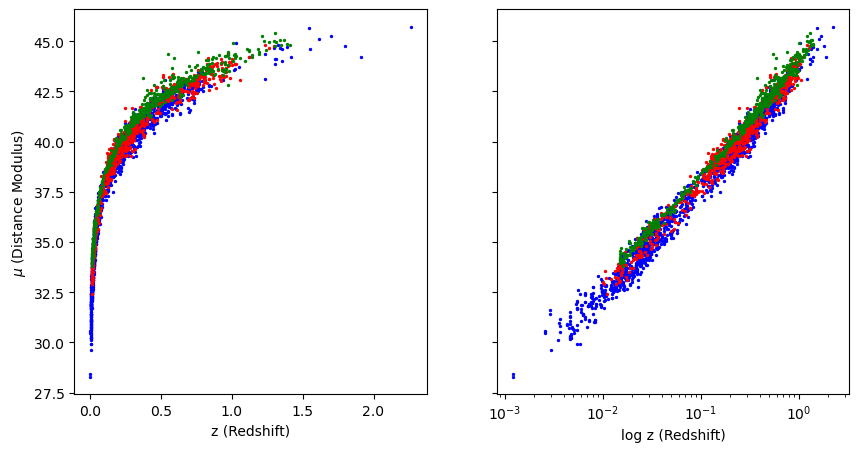

In [173]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10,5))
ax1.scatter(PS_data['zcmb'], PS_data['DM'], color='blue', s=2, label='Pantheon+SH0ES')
ax1.scatter(B_data['zcmb'], B_data['DM'], color='red', s=2, label='Betoule et al.')
ax1.scatter(SCP_data['zcmb'], SCP_data['DM'], color='green', s=2, label='SCP Union')

ax2.scatter(PS_data['zcmb'], PS_data['DM'], color='blue', s=2, label='Pantheon+SH0ES')
ax2.scatter(B_data['zcmb'], B_data['DM'], color='red', s=2, label='Betoule et al.')
ax2.scatter(SCP_data['zcmb'], SCP_data['DM'], color='green', s=2, label='SCP Union')

ax1.set_xlabel('z (Redshift)')
ax2.set_xlabel('log z (Redshift)')

ax1.set_ylabel(r'$\mu$ (Distance Modulus)');
ax2.set_xscale('log')

We can also use the distance modulus to calculate the luminosity distance, using the same formula for luminosity distance as above, but in terms of magnitudes:
\begin{equation}
d_L = 10^{0.2 * \mu}\times 10 pc
\end{equation}

In [174]:
#Convert it to GPC for easier plotting:
pc10_to_GPC = 1.e-8

B_data['dL'] = pc10_to_GPC*10.**(0.2*B_data['DM'])    #Luminosity distance in GPC

SCP_data['dL'] = pc10_to_GPC*10.**(0.2*SCP_data['DM'])    #Luminosity distance in GPC

PS_data['dL'] = pc10_to_GPC*10.**(0.2*PS_data['DM'])    #Luminosity distance in GPC


To compare this to the expected model given the accepted cosmological parameters from Planck (2018), we can set up a function to calculate the luminosity distance as a function of redshift, using $\Omega_m=0.3153$, $\Omega_{Lambda}=0.6847$, $\Omega_r=8.24\times10^{-5}$, and $H_0=67.36$km/s/Mpc.

The function numerically integrates the formula 
\begin{equation}
d_L(z) = (1+z)\frac{c}{H_0}\int_0^{z}\frac{1}{E(z)}, 
\end{equation}
where $E(z) = [\Omega_{\Lambda} + \Omega_m(1+z)^3 + \Omega_{r}(1+z)^4]^{1/2}$.

In [175]:
#Planck 2018 constants
Om = 0.3153
Ov = 0.6847
Or = 8.24E-5
H0 = 67.36 * (u.km / u.s / u.Mpc)
h = (H0/100).value

In [176]:
#Functions for numerical calculation of the luminosity distance as a function of z
def integrand_dL(z, Om, Ov, Or):
    '''Integrand for dL function; equal to 1/E(z) for a flat universe
    '''
    return (Ov + Om*(1+z)**3 + Or*(1+z)**4)**(-1/2)
    
def calc_dL(z_da, Om, Ov, Or, H0):
    '''Numerical calculation of the luminosity distance as a function of z
       For a flat universe with any values of omega_m, omega_^, omega_r, and H0
       
    Inputs: z, omega_m, omega_^, omega_r, H0 (1/s)
    Outputs: dL (meters)
    '''
    c_l = 2.99E8 #m/s
    dLz = (quad(integrand_dL, 0, z_da, (Om, Ov, Or))[0] * (c_l / H0)) * (1+z_da)
    return dLz

dL_func = np.vectorize(calc_dL)

Plotting the luminosity distances calculated for the data, alongside the model with accepted cosmological parameters:

Also plotting the distance moduli for the data and model, using the inverse of the formula written above:
\begin{equation}
\mu_c = 5 * \log_{10}(\frac{d_L}{10pc}):
\end{equation}

Text(0, 0.5, '$\\mu$ (Distance modulus)')

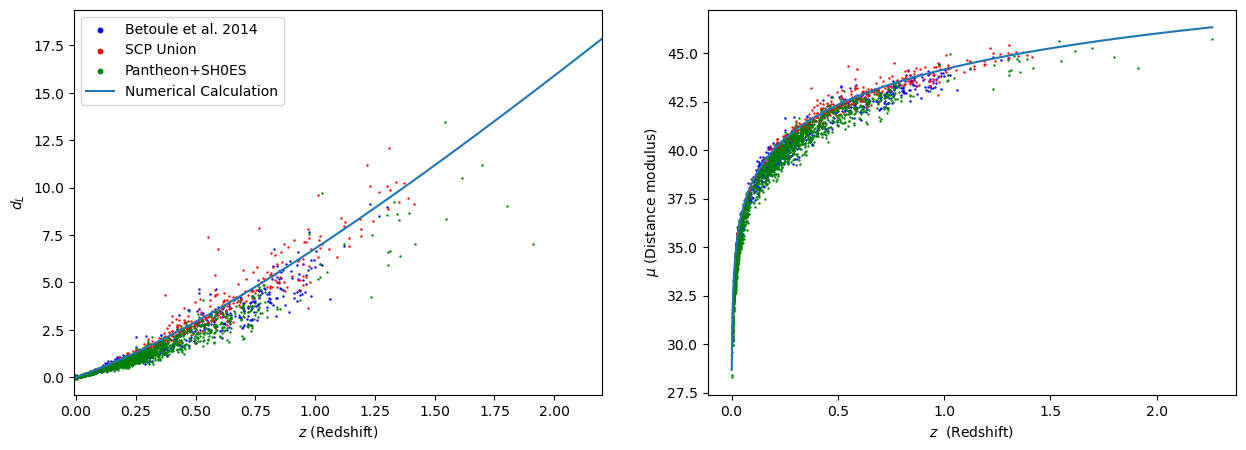

In [177]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

#Creating figure labels
ax1.scatter(0,0, s=10, c='b', label='Betoule et al. 2014')
ax1.scatter(0,0, s=10, c='r', label='SCP Union')
ax1.scatter(0,0, s=10, c='g', label='Pantheon+SH0ES')

#Plotting luminosity distance##########

ax1.set_xlim([-0.01, 2.2])
ax1.scatter(B_data['zcmb'], B_data['dL'], c='b', marker='.', s=2)
ax1.scatter(SCP_data['zcmb'], SCP_data['dL'], c='r', marker='.', s=2)
ax1.scatter(PS_data['zcmb'], PS_data['dL'], c='g', marker='.', s=2)

#Numerical solution:
zrange = np.linspace(min(PS_data['zcmb']), max(PS_data['zcmb']), 1000)
dLrange = dL_func(zrange, Om, Ov, Or, H0.to(1/u.s).value)*u.m.to(u.Gpc)

ax1.plot(zrange, dLrange, label='Numerical Calculation')

ax1.set_xlabel(r'$z$ (Redshift)')
ax1.set_ylabel(r'$d_L$')
ax1.legend();

#Plotting distance modulus##########

ax2.scatter(B_data['zcmb'], B_data['DM'], c='b', marker='.', s=2, label='Betoule et al. 2014')
ax2.scatter(SCP_data['zcmb'], SCP_data['DM'], c='r', marker='.', s=2, label='SCP Union')
ax2.scatter(PS_data['zcmb'], PS_data['DM'], c='g', marker='.', s=2, label='Pantheon Sh0es')

#Numerical solution:
zrange = np.linspace(min(PS_data['zcmb']), max(PS_data['zcmb']), 1000)
DMrange = 5 * np.log10((dL_func(zrange, Om, Ov, Or, H0.to(1/u.s).value)*u.m.to(u.pc)*u.pc / (10*u.pc)))

ax2.plot(zrange, DMrange, label='Numerical')

ax2.set_xlabel(r'$z$  (Redshift)')
ax2.set_ylabel(r'$\mu$ (Distance modulus)')


The model is a decent fit to the data, but from the plots it is apparent that a different model may fit the data better. Next, I attempt to fit the model using a non-linear least squares approach, and finally an MCMC approach.

# Fitting with Non-linear Least-Squares

In [178]:
#Using scipy.optimize.curve_fit
import scipy.optimize

I will use scipy.optimize.curve_fit to fit the data for $H_0$, $\Omega_m$, and $\Omega_{\Lambda}$.
The functions to numerically calculate $d_L$ for scipy.optimize.curve_fit must be altered slightly to accomodate z arrays as inputs:

In [179]:
def fit_cosm_consts(zvals, Om, Ov, H0):
    '''Use earlier dL calculation function, apply to an array of z values to calculate dL (simple loop)
    '''
    H0_s = (H0*(u.km / u.s / u.Mpc).to(1/u.s))
    Or = 8.24E-5
    dLs = []
    for zval in zvals:
        dL_zval = calc_dL(zval, Om, Ov, Or, H0_s)*u.m.to(u.Gpc)
        dLs.append(dL_zval)
    return np.array(dLs)

def fit_cosm_consts_DM(zvals, Om, Ov, H0):
    '''Use dL function that supports z arrays to calculate distance moduli for an input z array
    '''
    dLs = fit_cosm_consts(zvals, Om, Ov, H0)
    DM = 5 * np.log10(dLs*u.Gpc.to(u.pc)*u.pc / (10*u.pc))
    return DM

First, I will fit each dataset separately, using z<1 to exclude some apparent outliers:

In [180]:
#Selecting z<1:
z_l_1_B = B_data['zcmb'] < 1
z_l_1_SCP = SCP_data['zcmb'] < 1
z_l_1_PS = PS_data['zcmb'] < 1

#Bounds for omegas are 0-1, bounds for H0 are 0-100
bounds=((0, 0, 60), (1, 1, 100))

#Perform the curve fits, using errors from each dataset
fit_B = scipy.optimize.curve_fit(fit_cosm_consts, xdata=B_data['zcmb'][z_l_1_B], ydata=B_data['dL'][z_l_1_B], 
                                 p0=[Om, Ov, H0.value], bounds=bounds)

fit_SCP = scipy.optimize.curve_fit(fit_cosm_consts, xdata=SCP_data['zcmb'][z_l_1_SCP], ydata=SCP_data['dL'][z_l_1_SCP], 
                                 p0=[Om, Ov, H0.value], bounds=bounds)

fit_PS = scipy.optimize.curve_fit(fit_cosm_consts, xdata=PS_data['zcmb'][z_l_1_PS], ydata=PS_data['dL'][z_l_1_PS], 
                                 p0=[Om, Ov, H0.value], bounds=bounds)

In [181]:
print('Fit parameters B:')
print(r'Om', fit_B[0][0] )
print(r'Ov:', fit_B[0][1] )
print(r'H0:', fit_B[0][2])
print()
print('Fit parameters SCP:')
print(r'Om:', fit_SCP[0][0] )
print(r'Ov:', fit_SCP[0][1] )
print(r'H0:', fit_SCP[0][2])
print()
print('Fit parameters PS:')
print(r'Om:', fit_PS[0][0] )
print(r'Ov:', fit_PS[0][1] )
print(r'H0:', fit_PS[0][2])

Fit parameters B:
Om 0.3553887565124033
Ov: 0.7829138071462337
H0: 74.77518234804991

Fit parameters SCP:
Om: 0.42166704546272105
Ov: 0.42454644977729106
H0: 68.53251187973709

Fit parameters PS:
Om: 0.3677790702412553
Ov: 0.8210944790247403
H0: 79.97579808122107


These fits gave (ignoring errors for now):
1. Betoule dataset: $\Omega_m\sim0.36$, $\Omega_{\Lambda}\sim0.78$, and $H_0\sim74.78$
2. SCP Union dataset: $\Omega_m\sim0.42$, $\Omega_{\Lambda}\sim0.42$, and $H_0\sim68.53$
3. Pantheon+SH0ES dataset: $\Omega_m\sim0.36$, $\Omega_{\Lambda}\sim0.82$, and $H_0\sim79.98$

This is a large variance in results. Plotting them:

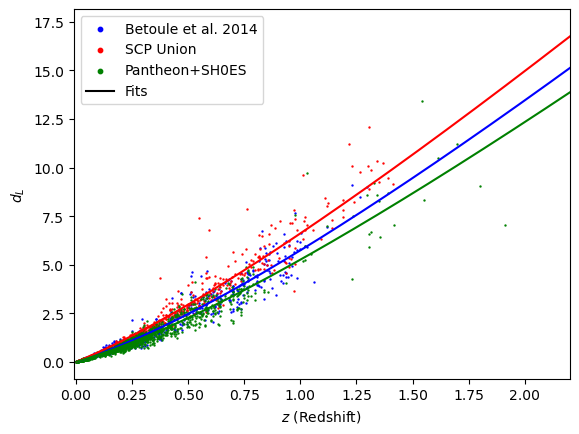

In [182]:
plt.scatter(-100,0, s=10, c='b', label='Betoule et al. 2014')
plt.scatter(-100,0, s=10, c='r', label='SCP Union')
plt.scatter(-100,0, s=10, c='g', label='Pantheon+SH0ES')

plt.plot(np.linspace(-100,-99,2), np.linspace(0,1,2), label='Fits', color='k')

plt.scatter(B_data['zcmb'], B_data['dL'], c='b', marker='.', s=2)
plt.scatter(SCP_data['zcmb'], SCP_data['dL'], c='r', marker='.', s=2)
plt.scatter(PS_data['zcmb'], PS_data['dL'], c='g', marker='.', s=2)
#Fitted solution:
zrange = np.linspace(min(PS_data['zcmb']), max(PS_data['zcmb']), 1000)
dL_Bfit = fit_cosm_consts(zrange, fit_B[0][0], fit_B[0][1], fit_B[0][2])

plt.plot(zrange, dL_Bfit, c='b')

dL_SCPfit = fit_cosm_consts(zrange, fit_SCP[0][0], fit_SCP[0][1], fit_SCP[0][2])

plt.plot(zrange, dL_SCPfit, c='r')

dL_PSfit = fit_cosm_consts(zrange, fit_PS[0][0], fit_PS[0][1], fit_PS[0][2])

plt.plot(zrange, dL_PSfit, c='g')

plt.xlabel(r'$z$ (Redshift)')
plt.ylabel(r'$d_L$')
plt.xlim([-0.01, 2.2])
plt.legend();


Fitting for distance modulus instead of luminosity distance may be better, since there is less variation:

In [183]:
#Perform the curve fits
fit_B = scipy.optimize.curve_fit(fit_cosm_consts_DM, xdata=B_data['zcmb'][z_l_1_B], ydata=B_data['DM'][z_l_1_B], 
                                 p0=[Om, Ov, H0.value], bounds=bounds)

fit_SCP = scipy.optimize.curve_fit(fit_cosm_consts_DM, xdata=SCP_data['zcmb'][z_l_1_SCP], ydata=SCP_data['DM'][z_l_1_SCP], 
                                 p0=[Om, Ov, H0.value], bounds=bounds)

fit_PS = scipy.optimize.curve_fit(fit_cosm_consts_DM, xdata=PS_data['zcmb'][z_l_1_PS], ydata=PS_data['DM'][z_l_1_PS], 
                                 p0=[Om, Ov, H0.value], bounds=bounds)

In [184]:
print('Fit parameters B:')
print(r'Om', fit_B[0][0] )
print(r'Ov:', fit_B[0][1] )
print(r'H0:', fit_B[0][2])
print()
print('Fit parameters SCP:')
print(r'Om:', fit_SCP[0][0] )
print(r'Ov:', fit_SCP[0][1] )
print(r'H0:', fit_SCP[0][2])
print()
print('Fit parameters PS:')
print(r'Om:', fit_PS[0][0] )
print(r'Ov:', fit_PS[0][1] )
print(r'H0:', fit_PS[0][2])

Fit parameters B:
Om 0.2826737355949602
Ov: 0.82009021727274
H0: 78.94431195963338

Fit parameters SCP:
Om: 0.2605984069535728
Ov: 0.6949352610178218
H0: 70.8173254900951

Fit parameters PS:
Om: 0.13848321212925002
Ov: 0.933236039837976
H0: 90.91087521014985


These fits gave (ignoring errors for now):
1. Betoule dataset: $\Omega_m\sim0.29$, $\Omega_{\Lambda}\sim0.82$, and $H_0\sim78.94$
2. SCP Union dataset: $\Omega_m\sim0.26$, $\Omega_{\Lambda}\sim0.69$, and $H_0\sim70.82$
3. Pantheon+SH0ES dataset: $\Omega_m\sim0.13$, $\Omega_{\Lambda}\sim0.93$, and $H_0\sim90.91$

Plotting them:

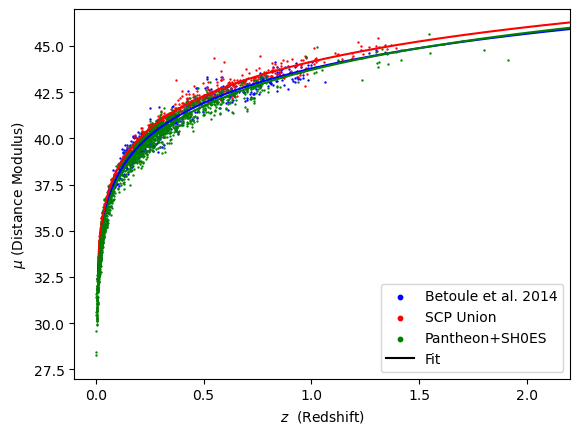

In [185]:
plt.scatter(-100,0, s=10, c='b', label='Betoule et al. 2014')
plt.scatter(-100,0, s=10, c='r', label='SCP Union')
plt.scatter(-100,0, s=10, c='g', label='Pantheon+SH0ES')

plt.plot(np.linspace(-100,-99,2), np.linspace(0,1,2), label='Fit', color='k')

plt.scatter(B_data['zcmb'], B_data['DM'], c='b', marker='.', s=2)
plt.scatter(SCP_data['zcmb'], SCP_data['DM'], c='r', marker='.', s=2)
plt.scatter(PS_data['zcmb'], PS_data['DM'], c='g', marker='.', s=2)

#Fitted solution:
zrange = np.linspace(min(B_data['zcmb']), max(PS_data['zcmb']), 1000)
dL_Bfit = fit_cosm_consts_DM(zrange, fit_B[0][0], fit_B[0][1], fit_B[0][2])

plt.plot(zrange, dL_Bfit, c='b')

dL_SCPfit = fit_cosm_consts_DM(zrange, fit_SCP[0][0], fit_SCP[0][1], fit_SCP[0][2])

plt.plot(zrange, dL_SCPfit, c='r')

dL_PSfit = fit_cosm_consts_DM(zrange, fit_PS[0][0], fit_PS[0][1], fit_PS[0][2])

plt.plot(zrange, dL_PSfit, c='g')

plt.xlabel(r'$z$  (Redshift)')
plt.ylabel(r'$\mu$ (Distance Modulus)')
plt.xlim([-0.1, 2.2])
plt.ylim([27, 47])
plt.legend();


There is still a lot of variation in the results. Now I combine all three datasets, including errors this time, and only selecting points with z<0.7 to constrain the model. To include errors from the datasets, I fit for the distance modulus.

In [186]:
#joining all data together
from astropy.table import join

SCP_data['DM Err'] = SCP_data['errDM']

tab_B_SCP = join(B_data['zcmb', 'dL', 'DM', 'DM Err'], SCP_data['zcmb', 'dL', 'DM', 'DM Err'], join_type='outer')
tab_all = join(tab_B_SCP, PS_data['zcmb', 'dL', 'DM', 'DM Err'], join_type='outer').filled(np.nan)


Fitting Distance Modulus:

In [187]:
#selecting z<0.7 and making sure there are no NaNs:
valid = np.isfinite(tab_all['zcmb']) & np.isfinite(tab_all['DM']) & np.isfinite(tab_all['DM Err'])
z_l_07 = (tab_all['zcmb'] < 0.7) & valid

#Performing fit, including errors:
fit_all = scipy.optimize.curve_fit(fit_cosm_consts_DM, xdata=tab_all['zcmb'][z_l_07], ydata=tab_all['DM'][z_l_07], 
                                   sigma = tab_all['DM Err'][z_l_07], p0=[Om, Ov, H0.value], bounds=bounds, 
                                   nan_policy='omit', absolute_sigma= True)

#Estimating errors with the curve_fit covariance matrix:
cov = fit_all[1]
errs = np.sqrt(np.diag(cov))

print('Fit parameters all:')
print(r'$\Omega_m$: %6.4f +- %6.4f' %(fit_all[0][0], errs[0]))
print(r'$\Omega_v$:  %6.4f +- %6.4f'%(fit_all[0][1], errs[1]))
print(r'$H_0$:  %6.4f +- %6.4f' %(fit_all[0][2], errs[2]))

Fit parameters all:
$\Omega_m$: 0.2057 +- 535.1034
$\Omega_v$:  0.8011 +- 2082.2620
$H_0$:  76.5818 +- 99535.5458


This fit gives:

$\Omega_m = 0.206\pm535$

$\Omega_{\Lambda} = 0.801\pm2082$

$H_0 = 76.58\pm99535$

These parameters seem decent, but the errors are enormous. To plot the results:

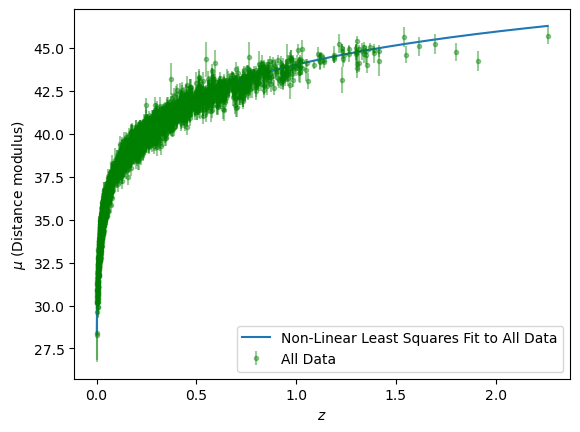

In [188]:
plt.errorbar(tab_all['zcmb'], tab_all['DM'], yerr=tab_all['DM Err'], c='g', marker='.', label='All Data', ls='', alpha=0.4)

#Numerical solution:
zrange = np.linspace(min(tab_all['zcmb']), max(tab_all['zcmb']), len(tab_all['zcmb']) )

DM_all = fit_cosm_consts_DM(zrange, fit_all[0][0], fit_all[0][1], fit_all[0][2])

plt.plot(zrange, DM_all, label='Non-Linear Least Squares Fit to All Data')

plt.xlabel(r'$z$')
plt.ylabel(r'$\mu$ (Distance modulus)')
plt.legend()
#plt.xscale('log')
#plt.yscale('log')

To compute the $\chi^2$:

In [189]:
def chisq(ndim, nparams, model, data, err):
    '''Calculate the reduced chi-squared from a data w/error and a model
    '''
    diff = model - data
    dof = ndim - nparams
    return np.sum(diff**2 / err**2) / dof

In [190]:
print('reduced chi-squared: %6.3f' %(chisq(len(tab_all['zcmb']), 3, DM_all, tab_all['DM'], tab_all['DM Err'])) )

reduced chi-squared: 242.469


To obtain more accurate on the parameters, I implement MCMC fitting.

# Using MCMC

I will be using the pymc package:

In [191]:
import pymc as pm
import pytensor.tensor as pt
import pytensor
import pymc_ext as pmx

Again, I select only valid numbers and values with z<0.7 to exclude as many outliers as possible.

In [192]:
#Select valid and z<0.7
valid = np.isfinite(tab_all['zcmb']) & np.isfinite(tab_all['DM']) & np.isfinite(tab_all['DM Err'])
z_l_1 = (tab_all['zcmb'] < 0.7) & (valid)

zcmb = tab_all['zcmb'][valid]
DM = tab_all['DM'][valid]
DM_err = tab_all['DM'][valid]

Then, I set up a pymc model which uses MCMC to fit for the best parameters. In order to do this, I first have to create a version of the fitting functions which uses tensor variables rather than numerical parameters and arrays. I will again fit for distance modulus so errors from the datasets can be used:

In [193]:
def distance_modulus_mcmc(z, Om, Ov, H0):
    '''Distance modulus function using PyTensor - used to fit parameters in pymc'''
    #Convert H0 to 1/s
    kmsMpc_s = pt.constant((u.km / u.s / u.Mpc).to(1/u.s))
    H0_s = H0*kmsMpc_s

    #Radiation density parameter
    Or = pt.constant(8.24E-5)

    #convert c to pc/s
    c_pc = pt.constant(c.c.to(u.pc/u.s).value) #pc/s

    def Integral(z):
        """Numerically integrate 1/E(z) function for given z"""
        zrange = pt.linspace(0, z, 1000)
        dz = zrange[1] - zrange[0]
        
        Ez = ((Om*(1 + zrange)**3 + Ov*(1 + zrange)**4 + Ov) ** -0.5)

        integral = pt.sum((Ez[:-1] + Ez[1:]) / 2 * dz)  #Trapezoidal rule

        return integral

    #Perform integral for each element in z tensor
    zvec = pt.vector('zvec')
    nstep = pt.iscalar('nstep')
    integrated, updates = pytensor.scan(fn=Integral, sequences=[zvec])
    integrate = pytensor.function(inputs=[zvec], outputs=integrated, updates=updates)

    #Calculate luminosity distance and distance modulus
    dL_s = (c_pc / H0) * (1 + z) * integrate(z)
    DMval = 50 * pt.log10(dL_s / 10)

    return DMval

Then, I create a pymc model and run it, using initial values from the nonlinear least squares fit. First, I will find the local maximum a posteriori point to make sure the model works, then run MCMC to fit the parameters.

In [194]:
with pm.Model() as dL_model:
    #Initialize parameters
    H0_param = pm.Normal('H0', mu=77, sigma=5, initval=77)
    Om_param = pm.Uniform('Om', lower=0, upper=1, initval=0.2)
    Ov_param = pm.Uniform('Ov', lower=0, upper=1, initval=0.8)

    #Apply function
    mu_mod = distance_modulus_mcmc(zcmb, Om_param, Ov_param, H0)

    #Fit to data
    mu_obs = pm.Normal("mu_obs", mu=mu_mod, sigma=DM_err, observed=DM)

    #Find local maximum a posteriori point - for testing the model before running MCMC
    map_soln = pm.find_MAP()

Output()

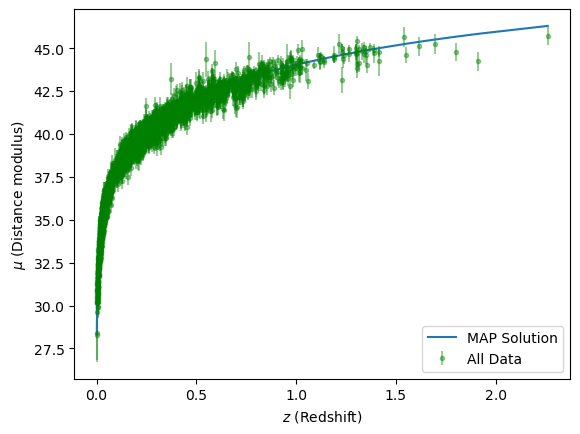

In [195]:
plt.errorbar(tab_all['zcmb'], tab_all['DM'], yerr=tab_all['DM Err'], c='g', marker='.', label='All Data', ls='', alpha=0.4)

#MAP solution:
plt.plot(zcmb, fit_cosm_consts_DM(zcmb, map_soln['Om'], map_soln['Ov'], map_soln['H0']), label='MAP Solution')

plt.xlabel(r'$z$ (Redshift)' )
plt.ylabel(r'$\mu$ (Distance modulus)')
plt.legend();
#plt.xscale('log')
#plt.yscale('log')

Based on the MAP solution, the model appears to fit the data well, so I will fit it with MCMC:

In [196]:
with dL_model:
    results = pmx.utils.sample(chains=5, draws=3000, tune=5000)

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_full...
/home/nervoushedgehog/miniconda3/envs/pymc/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:754: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (5 chains in 4 jobs)
NUTS: [H0, Om, Ov]


Output()

Sampling 5 chains for 5_000 tune and 3_000 draw iterations (25_000 + 15_000 draws total) took 10 seconds.


In [197]:
H0_MCMC_Fit = np.percentile(results.posterior["H0"].values, [16, 50, 84], axis=(0, 1),)
Om_MCMC_Fit = np.percentile(results.posterior["Om"].values, [16, 50, 84], axis=(0, 1),)
Ov_MCMC_Fit = np.percentile(results.posterior["Ov"].values, [16, 50, 84], axis=(0, 1),)

print('H0 Best fit: %6.2f-%6.2f+%6.2f' %(H0_MCMC_Fit[1], H0_MCMC_Fit[1]-H0_MCMC_Fit[0], H0_MCMC_Fit[2]-H0_MCMC_Fit[1]))
print('Om Best fit: %6.2f-%6.2f+%6.2f' %(Om_MCMC_Fit[1], Om_MCMC_Fit[1]-Om_MCMC_Fit[0], Om_MCMC_Fit[2]-Om_MCMC_Fit[1]))
print('Ov Best fit: %6.2f-%6.2f+%6.2f' %(Ov_MCMC_Fit[1], Ov_MCMC_Fit[1]-Ov_MCMC_Fit[0], Ov_MCMC_Fit[2]-Ov_MCMC_Fit[1]))

H0 Best fit:  76.94-  4.98+  5.03
Om Best fit:   0.49-  0.34+  0.35
Ov Best fit:   0.50-  0.34+  0.34


In [198]:
print(r'reduced chi-squared: %6.3f' %chisq(len(zcmb), 3, fit_cosm_consts_DM(zcmb, Om_MCMC_Fit[1], Ov_MCMC_Fit[1], H0_MCMC_Fit[1]), tab_all['DM'], tab_all['DM Err']))


reduced chi-squared:  1.682


This fit has a reduced $\chi^2$ of ~1.7, which is an improvement over the non-linear least square fitting model.

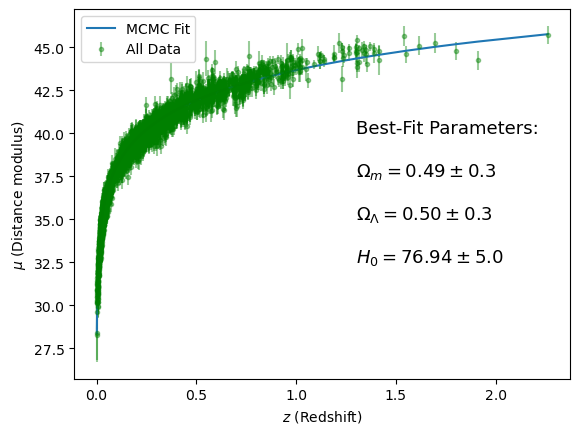

In [199]:
plt.errorbar(tab_all['zcmb'], tab_all['DM'], yerr=tab_all['DM Err'], c='g', marker='.', label='All Data', ls='', alpha=0.4)

#MCMC Solution
plt.plot(zcmb, fit_cosm_consts_DM(zcmb, Om_MCMC_Fit[1], Ov_MCMC_Fit[1], H0_MCMC_Fit[1]), label='MCMC Fit')

plt.text(1.3, 40.0, 'Best-Fit Parameters:', fontsize=13)
plt.text(1.3, 37.5, r'$\Omega_m=%6.2f\pm%6.1f$' %(Om_MCMC_Fit[1], Om_MCMC_Fit[1]-Om_MCMC_Fit[0]), fontsize=13)
plt.text(1.3, 35.0, r'$\Omega_{\Lambda}=%6.2f\pm%6.1f$' %(Ov_MCMC_Fit[1], Ov_MCMC_Fit[1]-Ov_MCMC_Fit[0]), fontsize=13)
plt.text(1.3, 32.5, r'$H_0=%6.2f\pm%6.1f$' %(H0_MCMC_Fit[1], H0_MCMC_Fit[1]-H0_MCMC_Fit[0]), fontsize=13)

plt.xlabel(r'$z$ (Redshift)')
plt.ylabel(r'$\mu$ (Distance modulus)')
plt.legend(loc=2);
#plt.xscale('log')
#plt.yscale('log')

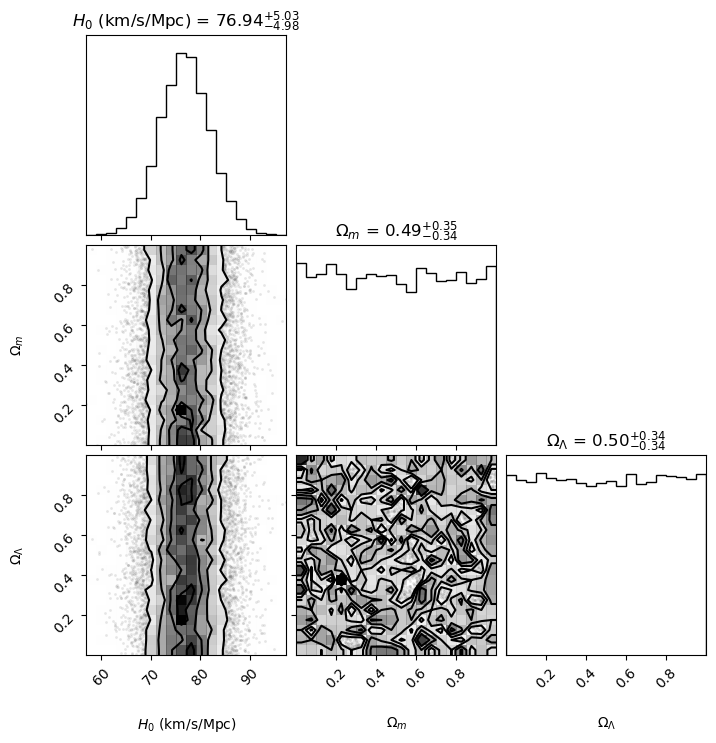

In [200]:
import corner
figure = corner.corner(results, show_titles=True, title_kwargs={"fontsize": 12}, 
                       labels=[r'$H_0$ (km/s/Mpc)', r'$\Omega_m$', r'$\Omega_{\Lambda}$'], figsize=(5,5));

The MCMC results have smaller errors than the non-linear least squares fits, and the reduced $\chi^2$ is closer to 1, although from the corner plot it is apparent that $\Omega_m$ and $\Omega_{\Lambda}$ did not converge very well. This makes sense because the two parameters have degenerate effects on the model. However, from the corner plot, it appears that the model converged well on a value for $H_0$.

The results were:

$\Omega_m = 0.49\pm0.34$

$\Omega_{\Lambda}=0.50\pm0.34$

$H_0=77\pm5$ km/s/Mpc

As a final check, I compare the $\chi^2$ of this fitted model compared to the model using cosmological constants from Planck 2018:

In [202]:
print('reduced chi-sq for this model: %6.4f' %chisq(len(zcmb), 3, fit_cosm_consts_DM(zcmb, Om_MCMC_Fit[1], Ov_MCMC_Fit[1],
                                                                       H0_MCMC_Fit[1]), tab_all['DM'], tab_all['DM Err']))

print('reduced chi-sq for literature values: %6.4f' %chisq(len(zcmb), 3, fit_cosm_consts_DM(zcmb, Om, Ov,
                                                                       H0.value), tab_all['DM'], tab_all['DM Err']))

reduced chi-sq for this model: 1.6817
reduced chi-sq for literature values: 2.0973


This shows that this model is a better fit to this dataset than the model with parameters from Planck 2018.

# Discussion and Conclusion

There are a few limiting factors of these datasets and my methods in this project. For one, the errors on the Pantheon+SH0ES data are only approximate, as the diagonals of the whole covariance matrix. This error-of-errors could impact the results of fits. In addition, it is apparent in plots that compare the three datasets that the Pantheon+SH0ES data has a consistently slightly lower luminosity distance and distance modulus than the other two datasets. This could be due to some correction which was applied by the Pantheon+SHOES team, or vice versa for the other two datasets. Regardless, this correlated difference between datasets is an indication that the three of them cannot necessarily be equivalently compared like I have in this project. Another source of error comes from the fitting algorithms---because the parameters $\Omega_m$, $\Omega_{\Lambda}$, and $H_0$ are related and change much less than the physical change in dataset values (i.e. changing two parameters $\sim$inversely by a lot may not change the output distance modulus or luminosity distance much), and the parameters have outside correlations which are not included in the fitting models, like how $\Omega_m + \Omega_{\Lambda} + \Omega_r = 1$, any model may struggle to fit the parameters.

Despite these challenges, the resulting best-fit parameters were semi-realistic and the expected values for both density parameters were within 1$\sigma$. Especially interesting is the fact that the value of $H_0$ was about 2$\sigma$ away from the value from Planck 2018---this is a demonstration of the Hubble Tension, a discrepancy in the measured value of $H_0$ between SN1a and CMB observations. As of now, it is unclear whether this is some error in the way the parameter is being measured in one or both methods, or a fundamental misunderstanding/misrepresentation of the universe. 